In [1]:
import numpy as np

In [2]:
length = 10
n_spines = 5
layers = 2
height = 6

offset = 2 * layers + 1
num_elements = layers * (n_spines-1) # total number of elements (triangles)
num_global_nodes = offset * n_spines

We create two matrices:
$$l = \begin{bmatrix} \ell_{1,1} & \cdots & \ell_{1,6} \\ \vdots & \ddots & \vdots \\ \ell_{i,1} & \cdots & \ell_{i,6} \end{bmatrix}_{i \times 6}$$
where $i$ is the total number of elements. Each element has 6 local nodes.
$$s =  \begin{bmatrix} c_{1,1} &  c_{1,2} \\ \vdots & \vdots \\ c_{k,1}  & c_{k,2} \end{bmatrix}_{k \times 2}$$
where $k$ is the total number of global nodes.

In [3]:
l = [[0] * 6] * num_elements
s = [[0, 0]] * num_global_nodes

In [4]:
for el in range(0, num_elements, 2):
    col = el // (2 * layers) # each column pair has 2m elements
    row = el % (2 * layers)
    start = col * 2 * offset + row

    l[el] = [start,
            start + 2 * offset,
            start + 2 * offset + 2,
            start + offset + 1,
            start + offset,
            start + 2 * offset + 1]
    
    l[el + 1] = [start,
                start + 2 * offset + 2,
                start + 2,
                start + 1,
                start + offset + 1,
                start + offset + 2]

for row in l:
    print(row)

[0, 10, 12, 6, 5, 11]
[0, 12, 2, 1, 6, 7]
[2, 12, 14, 8, 7, 13]
[2, 14, 4, 3, 8, 9]
[10, 20, 22, 16, 15, 21]
[10, 22, 12, 11, 16, 17]
[12, 22, 24, 18, 17, 23]
[12, 24, 14, 13, 18, 19]


In [5]:
def spine_height(i):
    '''
    A sine wave function that takes in ith spine (horizontally) and returns its height
    '''
    if i < n_spines:
        x_coord = i * length / (n_spines - 1)
        return height + np.sin(x_coord) # height of the spine varies around the initial height

In [ ]:
for gn in range(num_global_nodes):
    col, row = gn // offset, gn % offset
    h = spine_height(col)
    s[gn] = (col * length / (n_spines - 1), row / (2 * layers) * h)
s

# but sine wave is a continuous function, while my choices are discrete

[(0.0, np.float64(0.0)),
 (0.0, np.float64(1.5)),
 (0.0, np.float64(3.0)),
 (0.0, np.float64(4.5)),
 (0.0, np.float64(6.0)),
 (2.5, np.float64(0.0)),
 (2.5, np.float64(1.649618036025989)),
 (2.5, np.float64(3.299236072051978)),
 (2.5, np.float64(4.948854108077967)),
 (2.5, np.float64(6.598472144103956)),
 (5.0, np.float64(0.0)),
 (5.0, np.float64(1.2602689313342155)),
 (5.0, np.float64(2.520537862668431)),
 (5.0, np.float64(3.7808067940026464)),
 (5.0, np.float64(5.041075725336862)),
 (7.5, np.float64(0.0)),
 (7.5, np.float64(1.7344999941936847)),
 (7.5, np.float64(3.4689999883873694)),
 (7.5, np.float64(5.203499982581054)),
 (7.5, np.float64(6.937999976774739)),
 (10.0, np.float64(0.0)),
 (10.0, np.float64(1.3639947222776576)),
 (10.0, np.float64(2.7279894445553152)),
 (10.0, np.float64(4.091984166832972)),
 (10.0, np.float64(5.4559788891106304))]

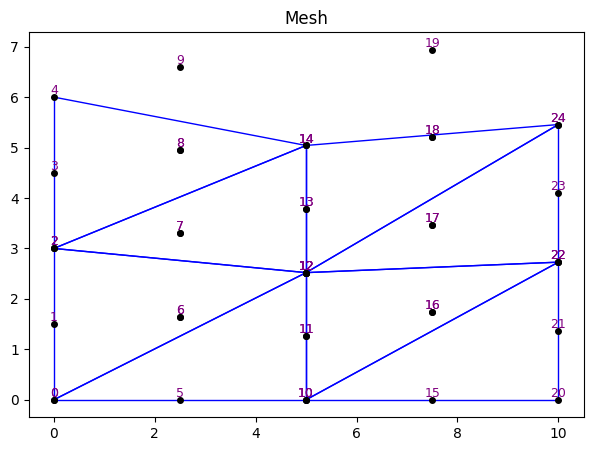

In [7]:
import matplotlib.pyplot as plt

def plot():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_aspect('equal')

    xs = [coord[0] for coord in s]
    ys = [coord[1] for coord in s]

    for nodes in l:
        for a, b in [(0,1),(1,2),(2,0)]:
            ax.plot([xs[nodes[a]], xs[nodes[b]]], [ys[nodes[a]], ys[nodes[b]]], 'b-', lw=1)
        for gn in nodes:
            ax.plot(xs[gn], ys[gn], 'ko', ms=4)
            ax.text(xs[gn], ys[gn], str(gn), fontsize=9, ha='center', va='bottom', color='purple')

    ax.set_title('Mesh')
    plt.show()


plot()